In [1]:
import numpy as np
from skimage import io, util, measure, transform
from scipy.ndimage import gaussian_filter
from scipy import interpolate
import pandas as pd
from imageUtils import normalize_image_intensity_signed

from os import path
import stackview
import matplotlib.pyplot as plt
# from scipy.interpolate import NearestNDInterpolator

from measurements import get_bm_image, get_mesh_from_bm_image,get_tissue_curvature_sparse, export_mesh
from trimesh import Trimesh
import pyvista as pv
pv.set_jupyter_backend('trame')

%load_ext autoreload
%autoreload 2


# Single cell curvature differences

In [2]:
dataset_dir = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Dataset pickles'
all_df = pd.read_pickle(path.join(dataset_dir,f'all_df.pkl'))
basals = pd.read_pickle(path.join(dataset_dir,f'basals.pkl'))
divisions = pd.read_pickle(path.join(dataset_dir,f'divisions.pkl'))
births = pd.read_pickle(path.join(dataset_dir,f'births.pkl'))
all_tracks = {trackID:t for trackID,t in all_df.reset_index().groupby('TrackID')}

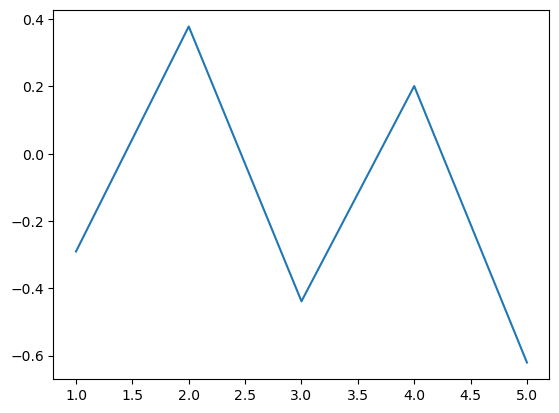

In [3]:
track = all_tracks['R1_3']
track = track[track['Cell type','Meta'] == 'Basal']
plt.plot(track['Frame'],track['Mean curvature 10um'])

(array([2.000e+00, 0.000e+00, 3.000e+00, 6.000e+00, 3.000e+00, 7.000e+00,
        3.200e+01, 3.100e+01, 2.800e+01, 5.000e+01, 1.060e+02, 1.080e+02,
        1.590e+02, 1.760e+02, 2.510e+02, 2.570e+02, 2.780e+02, 4.040e+02,
        4.750e+02, 6.480e+02, 6.780e+02, 7.320e+02, 8.860e+02, 9.620e+02,
        1.036e+03, 1.070e+03, 1.130e+03, 1.113e+03, 1.048e+03, 8.890e+02,
        7.750e+02, 5.860e+02, 4.380e+02, 2.500e+02, 1.440e+02, 1.090e+02,
        6.400e+01, 5.100e+01, 3.400e+01, 1.900e+01, 1.500e+01, 6.000e+00,
        2.000e+00, 3.000e+00, 4.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 3.000e+00]),
 array([-1.49291045, -1.43897703, -1.38504361, -1.3311102 , -1.27717678,
        -1.22324336, -1.16930995, -1.11537653, -1.06144311, -1.00750969,
        -0.95357628, -0.89964286, -0.84570944, -0.79177602, -0.73784261,
        -0.68390919, -0.62997577, -0.57604235, -0.52210894, -0.46817552,
        -0.4142421 , -0.36030869, -0.30637527, -0.25244185, -0.19850843,
        -0.

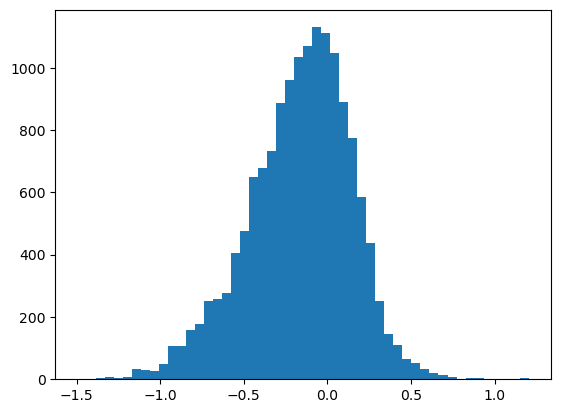

In [4]:
plt.hist(all_df['Mean curvature 5um'],50)

/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_22797/910569799.py:9: RuntimeWarning: Mean of empty slice.
  curv_diff[i] = np.diff(a).mean()
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   2.,   0.,
          0.,   0.,   1.,   0.,   1.,   0.,   0.,   1.,   2.,   2.,   5.,
          7.,   7.,   7.,  21.,  40.,  76., 162., 407., 684., 355., 115.,
         49.,  21.,  11.,   5.,   2.,   4.,   2.,   2.,   1.,   0.,   0.,
          1.,   0.,   0.,   2.,   0.,   3.]),
 array([-1.20741653, -1.16797008, -1.12852363, -1.08907718, -1.04963073,
        -1.01018428, -0.97073783, -0.93129138, -0.89184493, -0.85239848,
        -0.81295203, -0.77350558, -0.73405913, -0.69461268, -0.65516623,
        -0.61571978, -0.57627333, -0.53682688, -0.49738043, -0.45793398,
        -0.41848753, -0.37904108, -0.33959463, -0.30014818, -0.26070174,
        -0.22125529, -0.18180884, -0.14236239, -0.10291594, -0.06346949,
        -0.02402304,  0.01542341,  0.05486986,  0.09431631,  0.13376276,
         0.17320921,  0.21265566,  0.25210211,  0.29154856,  0.33099501,
         0.37044146,  0.40988791,  0.44933436,  0.48878081,  0.52822726,
 

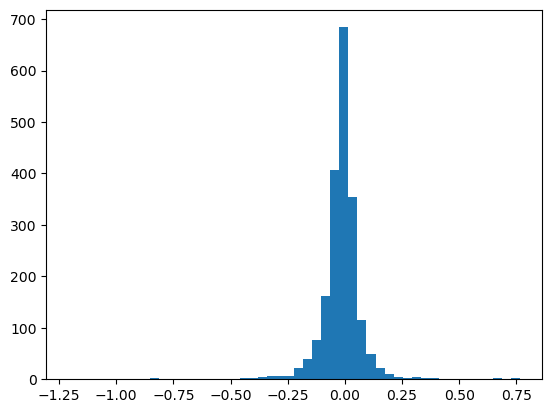

In [5]:
curv_diff = np.zeros(len(all_tracks))

num_sign_changes = np.zeros(len(all_tracks))

for i,track in enumerate(all_tracks.values()):
    
    a = track[track['Cell type','Meta'] == 'Basal'].droplevel(axis=1,level=1)['Mean curvature 5um']
    
    curv_diff[i] = np.diff(a).mean()
    num_sign_changes[i] = ((np.diff(np.sign(a)) != 0)*1).sum()
    
# for i,track in enumerate(all_tracks.values()):
#     curv_diff[i]= np.diff(track[track['Cell type','Meta'] == 'Basal'].droplevel(axis=1,level=1)['Mean curvature 5um']).mean()

plt.hist(curv_diff,50)

In [6]:
np.nanmean(curv_diff)

np.float64(-0.013838682397326779)

# Calculate curvature enmass

In [150]:
dirnames = {
            'M1_R2_t0':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/Curvature longevity/09-27-2025 MemGFP fold logevity/F1 cage 3015 MemGFP NoFUCCI/R2/0. Day 0',
            'M1_R2_t1':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/Curvature longevity/09-27-2025 MemGFP fold logevity/F1 cage 3015 MemGFP NoFUCCI/R2/1. Day 18',
            'M1_R3_t0':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/Curvature longevity/09-27-2025 MemGFP fold logevity/F1 cage 3015 MemGFP NoFUCCI/R3/0. Day 0',
            'M1_R3_t1':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/Curvature longevity/09-27-2025 MemGFP fold logevity/F1 cage 3015 MemGFP NoFUCCI/R3/1. Day 18',
            'M2_R1_t0':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/Curvature longevity/09-27-2025 MemGFP fold logevity/Mgray cage 2157 MemGFP FUCCI/R1/0. Day 0',
            'M2_R1_t1':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/Curvature longevity/09-27-2025 MemGFP fold logevity/Mgray cage 2157 MemGFP FUCCI/R1/1. Day 21',
            'M2_R2_t0':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/Curvature longevity/09-27-2025 MemGFP fold logevity/Mgray cage 2157 MemGFP FUCCI/R2/0. Day 0',
            'M2_R2_t1':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/Curvature longevity/09-27-2025 MemGFP fold logevity/Mgray cage 2157 MemGFP FUCCI/R2/1. Day 21',
            'M3_R1_t0':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/Curvature longevity/10-03-2025 Cdh5-RFP blood vessels/Male 6121/Left paw R1/0. Day 0',
            'M3_R1_t1':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/Curvature longevity/10-03-2025 Cdh5-RFP blood vessels/Male 6121/Left paw R1/1. Day 11',
            'M3_R1_t2':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/Curvature longevity/10-03-2025 Cdh5-RFP blood vessels/Male 6121/Left paw R1/2. Day 28',
            'M3_R2_t0':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/Curvature longevity/10-03-2025 Cdh5-RFP blood vessels/Male 6121/Left paw R2/0. Day 0',
            'M3_R2_t1':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/Curvature longevity/10-03-2025 Cdh5-RFP blood vessels/Male 6121/Left paw R2/1. Day 11',
            'M3_R2_t2':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/Curvature longevity/10-03-2025 Cdh5-RFP blood vessels/Male 6121/Left paw R2/2. Day 28',
           }

In [42]:
dirname

''

In [151]:
recalculate = False

heightmaps = {}
height_images = {}
# Load heightmaps if exists if not calculate
for name,dirname in dirnames.items():
    file = path.join(dirname,'height_image.tif')
    
    if path.exists(file) and not recalculate:
        height_images[name] = io.imread(file)
        heightmaps[name] = io.imread(path.join(dirname,'heightmap.tif'))
    else:
        B = io.imread(path.join(dirname,'B_reg.tif'))
        heightmap,height_image = get_bm_image(B,
                                              sigmas=[10,20,20], gradient_sign=+1,
                                              method='threshold', threshold=0.2)
        io.imsave(path.join(dirname,'height_image.tif'), height_image)
        io.imsave(path.join(dirname,'heightmap.tif'), heightmap)
        height_images[name] = height_image
        heightmaps[name] = heightmap
        

In [154]:
from measurements import get_tissue_curvature_over_grid,get_tissue_curvature_sparse

recalculate = False

dx = 0.2919921875
dz = 0.7

mean_curve = {}
gaussian_curve = {}
for name,dirname in dirnames.items():
    
    mesh = get_mesh_from_bm_image(height_images[name],
                                  spacing=[dz,dx,dx],decimation_factor=60)
    export_mesh(mesh,path.join(dirname,'mesh.npz'),values = mean_curvature)

    if not path.exists(path.join(dirname,'mean_curvature_kappa5.npz')) or recalculate:
        mean_curvature,gaussian_curvature = \
            get_tissue_curvature_over_grid(mesh,image_shape=height_images[name].shape)
    
        print(mean_curvature.shape)
        np.savez(path.join(dirname,'mean_curvature_kappa5.npz'),mean_curvature=mean_curvature,gaussian_curvature=gaussian_curvature)
    

(1024, 1024)


In [ ]:
pl = pv.Plotter(notebook=True)
mesh = Trimesh(v[:,[1,2,0]],f)
pl.add_mesh(mesh)
pl.show(jupyter_backend='trame')

# Load calculated curvatures

In [255]:
# Load single timepoint ones

from glob import glob
from pathlib import Path
from re import findall

dirname = Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/Curvature longevity')
expt_names = ['09-27-2025 MemGFP fold logevity','10-03-2025 Cdh5-RFP blood vessels']

filelist = list(dirname.rglob( '**/mean_curvature_kappa5.npz'))

# Parse filename for time signature
manifest = pd.DataFrame()
manifest['filename'] = filelist
manifest['subdir_name'] = manifest['filename'].apply(lambda x: str(x.parent.name))
manifest['Delay'] = manifest['subdir_name'].apply(lambda x: int(findall(r'(\d+). Day (\d+)',x)[0][1]))
manifest['Region'] = manifest['filename'].apply(lambda x: x.parents[1].name)
manifest['Mouse'] = manifest['filename'].apply(lambda x: x.parents[2].name)
manifest['Experiment'] = manifest['filename'].apply(lambda x: x.parents[3].name)

manifest['Mouse_Region'] = manifest['Mouse'] + '_' + manifest['Region']
manifest['name'] = manifest['Mouse'] + '_' + manifest['Region'] + '_t' + manifest['Delay'].astype(str)
manifest

curvatures = {}
for idx, row in manifest.iterrows():
    curvatures[row['Mouse_Region'], row['Delay']] = np.load(row['filename'])['mean_curvature']

[x.shape for x in curvatures.values()]

[(1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024)]

In [256]:
# Manually load the mesa ones
mouse = ['R1','R2']

for m in mouse:
    for t in range(15):
        name = f'Mesa_{m}'
        curvatures[name,t/2] = \
            np.load(f'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/W-{m}/Image flattening/trimesh/mean_curvature_t{t}_kappa5.npz')['mean_curvature']
# Append Mesa datas to manifest chart
mesa = pd.DataFrame()
mesa['Delay'] = list(range(15)) * 2
mesa['Mouse'] = ['Mesa'] * 30
mesa['Region'] = ['R1']*15 + ['R2']*15
mesa['Mouse_Region'] = ['Mesa_R1']*15 + ['Mesa_R2']*15
mesa['Delay'] /= 2
manifest = pd.concat((manifest,mesa),ignore_index=True)

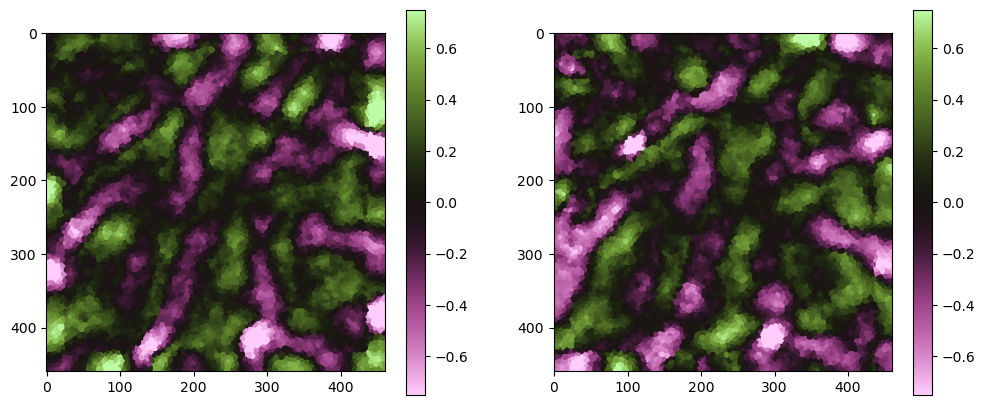

In [258]:
mouse = 'Mesa_R1'

plt.rcParams['figure.figsize'] = [12, 5]
plt.subplot(1,2,1)
plt.imshow(curvatures[(mouse,0)],vmin=-0.75,vmax=0.75,cmap='vanimo')
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(curvatures[(mouse,4.5)],vmin=-0.75,vmax=0.75,cmap='vanimo')
plt.colorbar()

# plt.gcf().savefig(path.join(dirnames[mouse+'_t0'],'curvature_stability'))

In [259]:
mouse_regions = {name:g for name,g in manifest.groupby('Mouse_Region')}
mouse_regions.keys()

dict_keys(['F1 cage 3015 MemGFP NoFUCCI_R2', 'F1 cage 3015 MemGFP NoFUCCI_R3', 'Male 6121_Left paw R1', 'Male 6121_Left paw R2', 'Mesa_R1', 'Mesa_R2', 'Mgray cage 2157 MemGFP FUCCI_R1', 'Mgray cage 2157 MemGFP FUCCI_R2'])

In [260]:
# Align and save aligned
from pystackreg import StackReg
from skimage import transform
from collections import defaultdict

Xtrim = slice(100,900)
Ytrim = slice(100,900)

curvatures_aligned = {}
delays = defaultdict(list)

for mouse,mouse_delays in mouse_regions.items():
    print(mouse)
    for _,row in mouse_delays.iterrows():
        if row['Delay'] == 0:
            curvatures_aligned[(mouse,0)] = curvatures[(mouse,0)]
            continue
        sr = StackReg(StackReg.RIGID_BODY)
        T = sr.register(curvatures[(mouse,0)][Xtrim,Ytrim],
                        curvatures[(mouse,row['Delay'])][Xtrim,Ytrim])
        
        T = transform.EuclideanTransform(T)
        transformed = transform.warp(curvatures[(mouse,row['Delay'])],T)
        curvatures_aligned[(mouse,row['Delay'])] = transformed
        delays[mouse].append(row['Delay'])

F1 cage 3015 MemGFP NoFUCCI_R2
F1 cage 3015 MemGFP NoFUCCI_R3
Male 6121_Left paw R1
Male 6121_Left paw R2
Mesa_R1
Mesa_R2
Mgray cage 2157 MemGFP FUCCI_R1
Mgray cage 2157 MemGFP FUCCI_R2


In [261]:
from mathUtils import normxcorr2

spatial_corrs = {}
for mouse in mouse_regions.keys():

    for tau in delays[mouse]:
        C = normxcorr2(curvatures_aligned[(mouse,0)][Xtrim,Ytrim],
                       curvatures_aligned[(mouse,tau)][Xtrim,Ytrim])
        # fig = plt.figure()
        # plt.imshow(C[ 1*int(len(C)/4):3*int(len(C)/4), 1*int(len(C)/4):3*int(len(C)/4) ])
        # plt.clim([0,.7])
        
        # fig.gca().set_aspect('equal', 'box')
        # plt.colorbar()
        # # fig.savefig(path.join(dirname,'spatial_correlation.svg'))
        spatial_corrs[(mouse,tau)] = C


In [262]:
plt.close('all')
spatial_corrs.keys()

dict_keys([('F1 cage 3015 MemGFP NoFUCCI_R2', 18.0), ('F1 cage 3015 MemGFP NoFUCCI_R3', 18.0), ('Male 6121_Left paw R1', 28.0), ('Male 6121_Left paw R1', 11.0), ('Male 6121_Left paw R2', 28.0), ('Male 6121_Left paw R2', 11.0), ('Mesa_R1', 0.5), ('Mesa_R1', 1.0), ('Mesa_R1', 1.5), ('Mesa_R1', 2.0), ('Mesa_R1', 2.5), ('Mesa_R1', 3.0), ('Mesa_R1', 3.5), ('Mesa_R1', 4.0), ('Mesa_R1', 4.5), ('Mesa_R1', 5.0), ('Mesa_R1', 5.5), ('Mesa_R1', 6.0), ('Mesa_R1', 6.5), ('Mesa_R1', 7.0), ('Mesa_R2', 0.5), ('Mesa_R2', 1.0), ('Mesa_R2', 1.5), ('Mesa_R2', 2.0), ('Mesa_R2', 2.5), ('Mesa_R2', 3.0), ('Mesa_R2', 3.5), ('Mesa_R2', 4.0), ('Mesa_R2', 4.5), ('Mesa_R2', 5.0), ('Mesa_R2', 5.5), ('Mesa_R2', 6.0), ('Mesa_R2', 6.5), ('Mesa_R2', 7.0), ('Mgray cage 2157 MemGFP FUCCI_R1', 21.0), ('Mgray cage 2157 MemGFP FUCCI_R2', 21.0)])

In [263]:
import seaborn as sb

Cmax = pd.DataFrame(index=range(len(spatial_corrs)))
for i,(key,C) in enumerate(spatial_corrs.items()):
    Cmax.loc[i,'Rmax'] = C.max()
    Cmax.loc[i,'Mouse_region'] = key[0]
    Cmax.loc[i,'Delay'] = key[1]

Cmax[['Mouse','Region']] = Cmax['Mouse_region'].str.split('_',expand=True)[[0,1]]


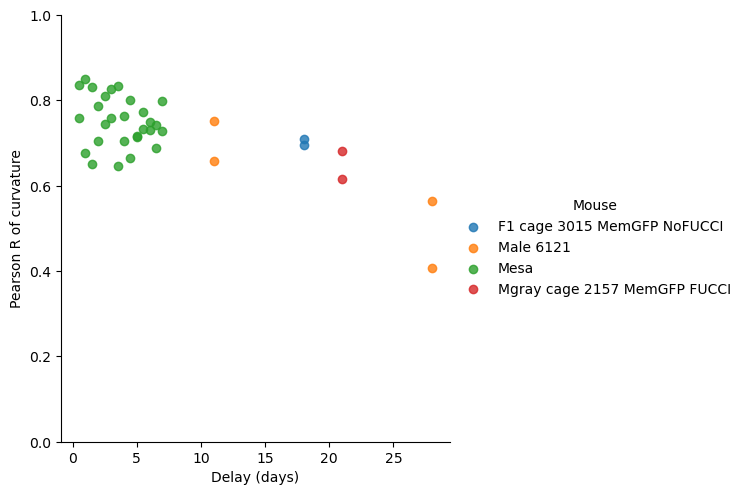

In [265]:
# Plot the decay
sb.lmplot(Cmax, y='Rmax', x='Delay',hue='Mouse',fit_reg=False)
plt.ylim([0,1])
plt.xlabel('Delay (days)')
plt.ylabel('Pearson R of curvature')

plt.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/Curvature longevity/Rmax_v_tau.svg')

In [21]:
from mathUtils import normxcorr2

meanC = np.mean(np.stack(list(spatial_corrs.values())),axis=0)
plt.imshow(meanC[ 1*int(len(meanC)/4):3*int(len(meanC)/4), 1*int(len(meanC)/4):3*int(len(meanC)/4) ])
plt.clim([0,1])
plt.gca().set_aspect('equal', 'box')
plt.colorbar()
plt.gcf().savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/mean_spatial_correlation.svg')


NameError: name 'spatial_corrs' is not defined

In [ ]:
import seaborn as sb

sb.stripplot([C.max() for _,C in spatial_corrs.items()])
# sb.boxplot([C.max() for _,C in spatial_corrs.items()])
plt.ylim([0,1])

print( f'Mean: {np.mean([C.max() for _,C in spatial_corrs.items()])}')
print( f'SEM: {np.std([C.max() for _,C in spatial_corrs.items()])/np.sqrt(len(spatial_corrs))}')

# Save

In [52]:
# Plot alongside the raw images
t0_R = io.imread(path.join(dirname,'0. Day 0/G_reg.tif'))
t1_R = io.imread(path.join(dirname,'1. Day 18/G_reg.tif'))

MIP_t0_R = t0_R.max(axis=0)[Y_trim,X_trim]
MIP_t1_R = t1_R.max(axis=0)[Y_trim,X_trim]

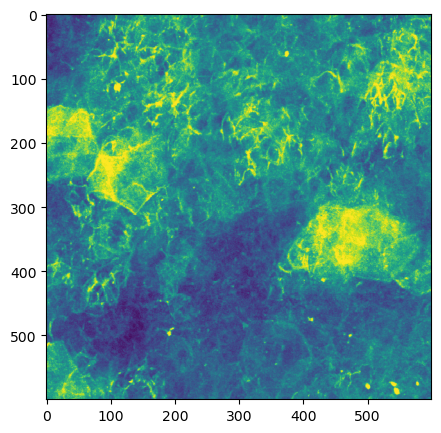

In [53]:
plt.imshow(MIP_t0_R)

In [67]:
t0_curvature

array([-1.67449531, -0.54555334,  0.0944696 , ...,  0.5581811 ,
        0.50719127,  0.5701386 ])

# Use mesh to reslice iomages

In [47]:
from measurements import reslice_by_heightmap
Z = 20

collagens = {}
collagen_mips = {}
for name,dirname in dirnames.items():
    
    f = path.join(dirname,'B_flat.tif')
    if path.exists(f) and not recalculate:
        collagens[name] = io.imread(f)
        collagen_mips[name] = collagens[name].max(axis=0)
    else:
        heightmap = heightmaps[name]
        B = io.imread(path.join(dirname,'B_reg.tif'))
        Bflat = reslice_by_heightmap(B,heightmap, 0, Z)
        io.imsave(f,Bflat)
        collagens[name] = Bflat
        collagen_mips[name] = Bflat.max(axis=0)

In [62]:
name = 'M2_R2_t0'
stackview.switch({'collagen':collagen_mips[name],'mean_curv':mean_curve[name].T},
                 colormap = ['pure_red','pure_green'],toggleable=True,zoom_factor=0.5)

In [58]:
collagen_mips[name].shape

(1024, 1024)

/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


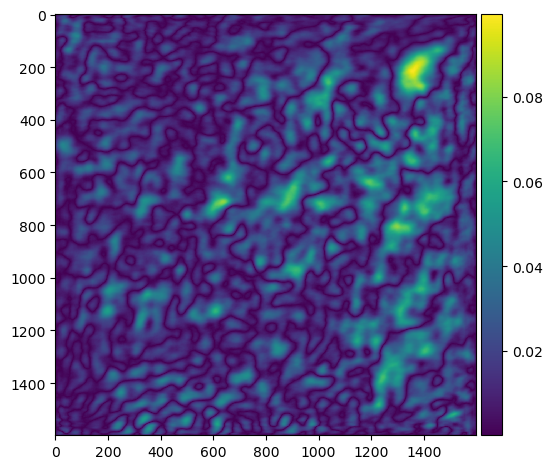

In [59]:
C = normxcorr2(collagen_mips[name][Xtrim,Ytrim],mean_curve[name][Xtrim,Ytrim])
io.imshow(C)